# Gaussian Mixture Models & EM — a step-by-step, runnable notebook

[K-means](../../01-K-Means-Clustering/01-K-Means-Clustering.md) hands every point a single hard label and can only draw round clusters. A **Gaussian Mixture Model** does something more honest: it assumes the data was *generated* by a handful of Gaussians — each with its own location, elliptical shape, and share of the data — and it infers, for every point, the **probability** that each Gaussian produced it. Those soft probabilities (**responsibilities**) are the whole point. The algorithm that fits it is **Expectation–Maximization (EM)**: alternately compute the responsibilities (E-step) and re-fit each Gaussian from them (M-step), and the data log-likelihood provably climbs at every step.

This notebook builds that, one measurement at a time, on **real scikit-learn data** (no download): **Iris** (150 flowers, 4 measurements, 3 species), standardized, carries the load-bearing claims — the from-scratch/scikit-learn match and the soft-beats-hard result. Its real **2-D petal plane** makes EM's ellipses visible; the **sheared anisotropic blobs** are the exact clusters k-means fails on in chapter 01. Every function used here lives in `gmm_em.py`, imported so the notebook and the module can never drift apart.

By the end you will have **measured**, not just been told:

1. the **mixture density** and the **responsibility** (soft assignment via Bayes' rule);
2. the **E-step** (log-sum-exp) and the closed-form **M-step**;
3. the EM loop with its log-likelihood **rising monotonically** to convergence;
4. the from-scratch fit **matching scikit-learn** on real Iris (same log-likelihood, ARI = 1.0);
5. **soft beating hard** and the GMM **succeeding where k-means fails** on sheared clusters;
6. **covariance types**, **BIC/AIC** model selection, and the **k-means limit**.

Everything runs on CPU in a few seconds, seeded for reproducibility.

## Step 0 — Setup and version banner

We import the real functions from the chapter module (so this notebook uses the *exact same code* the figures and the page use) and print the library versions the results were produced on.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

from gmm_em import (
    e_step, m_step, GMMScratch, em_history,
    verify_against_sklearn, compare_shape, select_k, compare_covariance_types,
    soft_vs_hard_ari, kmeans_limit_ari, temperature_responsibility,
    worked_example_1_responsibility, worked_example_2_one_em_step,
    load_iris_scaled, load_iris_petal_2d, load_anisotropic, load_blobs_3, IRIS_K,
)
from scipy.stats import norm

print(f'numpy {np.__version__} | scipy {scipy.__version__} | scikit-learn {sklearn.__version__}')
iris = load_iris_scaled()
petal = load_iris_petal_2d()
print(f'Iris  : {iris.x.shape[0]} flowers x {iris.x.shape[1]} standardized features, '
      f'true k = {iris.true_k}')
print(f'Petal : {petal.x.shape[0]} x 2 (real 2-D view for the animation)')

numpy 2.4.6 | scipy 1.17.1 | scikit-learn 1.9.0
Iris  : 150 flowers x 4 standardized features, true k = 3
Petal : 150 x 2 (real 2-D view for the animation)


## Step 1 — The mixture density: a weighted sum of Gaussians

A GMM assumes each point was made by a two-stage process: **roll a weighted die** to pick a component $k$ (probability $\pi_k$), then **draw** $x \sim \mathcal{N}(\mu_k, \Sigma_k)$. Marginalizing out the hidden choice gives the density

$$p(x) = \sum_{k=1}^{K} \pi_k\, \mathcal{N}(x;\mu_k,\Sigma_k).$$

Unlike a single Gaussian (one bump), a mixture can be **multimodal**. Here is a 1-D two-component mixture evaluated on a grid — note the two peaks a single Gaussian could never fit.

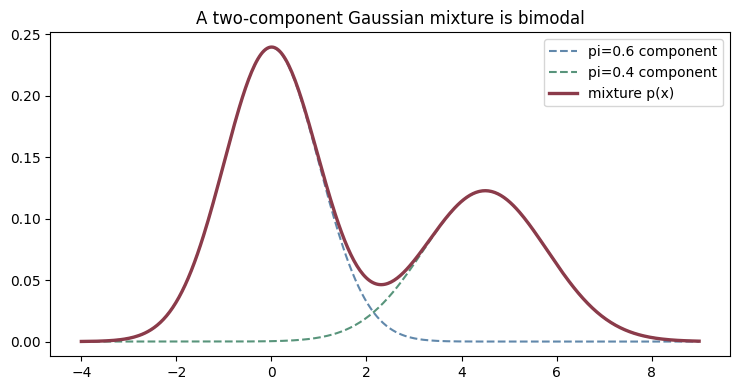

total probability integrates to ~1: 0.9999


In [2]:
grid = np.linspace(-4, 9, 400)
pi = [0.6, 0.4]
comps = [norm(0.0, 1.0), norm(4.5, 1.3)]
px = pi[0] * comps[0].pdf(grid) + pi[1] * comps[1].pdf(grid)
plt.figure(figsize=(7.5, 4))
for w, c, col in zip(pi, comps, ['#3A6B96', '#2E7A5A']):
    plt.plot(grid, w * c.pdf(grid), '--', color=col, alpha=0.8, label=f'pi={w} component')
plt.plot(grid, px, color='#8B3B4A', lw=2.4, label='mixture p(x)')
plt.title('A two-component Gaussian mixture is bimodal')
plt.legend()
plt.tight_layout()
plt.show()
print(f'total probability integrates to ~1: {np.trapezoid(px, grid):.4f}')

## Step 2 — The responsibility: a soft assignment by Bayes' rule

The **responsibility** $\gamma(z_{nk})$ is the posterior probability component $k$ generated point $x_n$ — prior $\pi_k$ times likelihood $\mathcal{N}(x_n;\mu_k,\Sigma_k)$, normalized:

$$\gamma(z_{nk}) = \frac{\pi_k\,\mathcal{N}(x_n;\mu_k,\Sigma_k)}{\sum_j \pi_j\,\mathcal{N}(x_n;\mu_j,\Sigma_j)}.$$

Worked Example 1: components $\mathcal{N}(0,1)$ and $\mathcal{N}(4,1)$, equal priors, a point at $x=1$. It is strongly — but not certainly — component A, the nuance k-means cannot express.

In [3]:
ex1 = worked_example_1_responsibility()
print(f"gamma_A(x=1), equal priors      = {ex1['gamma_A_equal_prior']:.4f}  (98.2% A, not 100%)")
print(f"gamma_A(x=1), priors 0.7/0.3    = {ex1['gamma_A_prior_0.7']:.4f}  (prior tilts it further to A)")
# by hand: 0.5*N(1;0,1) / (0.5*N(1;0,1) + 0.5*N(1;4,1))
pa, pb = 0.5 * norm(0, 1).pdf(1.0), 0.5 * norm(4, 1).pdf(1.0)
print(f'by hand                         = {pa / (pa + pb):.4f}  (matches)')

gamma_A(x=1), equal priors      = 0.9820  (98.2% A, not 100%)
gamma_A(x=1), priors 0.7/0.3    = 0.9922  (prior tilts it further to A)
by hand                         = 0.9820  (matches)


## Step 3 — One full E/M iteration by hand on {1, 2, 4, 7}

Worked Example 2: four points, $K=2$, initialized $\mu_A=2,\mu_B=6$, $\sigma^2=2$, equal weights. The **E-step** gives responsibilities (the point at $x=4$, exactly between the means, splits a perfect 50/50). The **M-step** re-estimates from the *soft counts* $N_k=\sum_n\gamma_{nk}$: $\pi_k=N_k/N$, $\mu_k=\frac{1}{N_k}\sum_n\gamma_{nk}x_n$, and the weighted variance. One iteration already separates the means and adapts the weights.

In [4]:
ex2 = worked_example_2_one_em_step()
print(f"E-step responsibilities gamma_A = {np.round(ex2['gamma_A'], 4)}  (x=4 splits 0.5/0.5)")
print(f"M-step soft count N_A           = {ex2['N_A']:.3f}")
print(f"       weight  pi_A             = {ex2['pi_A']:.3f}")
print(f"       means   mu_A, mu_B       = {ex2['mu_A']:.3f}, {ex2['mu_B']:.3f}")
print(f"       vars    var_A, var_B     = {ex2['var_A']:.3f}, {ex2['var_B']:.3f}  "
      '(A shrinks to hug 1,2; B stretches to reach 7)')

E-step responsibilities gamma_A = [0.9975 0.982  0.5    0.0025]  (x=4 splits 0.5/0.5)
M-step soft count N_A           = 2.482
       weight  pi_A             = 0.621
       means   mu_A, mu_B       = 2.006, 5.943
       vars    var_A, var_B     = 1.233, 2.202  (A shrinks to hug 1,2; B stretches to reach 7)


## Step 4 — The E-step in code: responsibilities via log-sum-exp

In more than a couple of dimensions the raw density $\mathcal{N}(x;\mu,\Sigma)$ **underflows to 0**, and $\gamma=0/0$ becomes `NaN`. The fix (which scikit-learn also uses) is to work in **log-space** and normalize with `logsumexp`. `e_step` returns the responsibilities *and* the observed-data log-likelihood. Two invariants to check: every row of $\gamma$ sums to 1, and the responsibilities are genuinely soft (values strictly between 0 and 1).

In [5]:
gm0 = GMMScratch(n_components=IRIS_K, n_init=1, seed=42).fit(iris.x)
resp, ll = e_step(iris.x, gm0.weights_, gm0.means_, gm0.covs_)
print(f'responsibilities shape : {resp.shape}  (n points x k components)')
print(f'every row sums to 1    : {np.allclose(resp.sum(axis=1), 1.0)}')
print(f'observed-data log-lik  : {ll:.4f}')
frac_soft = np.mean((resp.max(axis=1) < 0.999))
print(f'fraction of points with a genuinely soft (<0.999) top responsibility: {frac_soft:.2f}')

responsibilities shape : (150, 3)  (n points x k components)
every row sums to 1    : True
observed-data log-lik  : -290.5311
fraction of points with a genuinely soft (<0.999) top responsibility: 0.27


## Step 5 — The M-step: closed-form, responsibility-weighted updates

With the responsibilities fixed, each parameter has a closed form — the ordinary single-Gaussian MLE, but counting each point by its **soft** responsibility instead of a hard 0/1:

$$N_k=\sum_n\gamma_{nk},\quad \pi_k=\frac{N_k}{N},\quad \mu_k=\frac{1}{N_k}\sum_n\gamma_{nk}x_n,\quad \Sigma_k=\frac{1}{N_k}\sum_n\gamma_{nk}(x_n-\mu_k)(x_n-\mu_k)^\top.$$

The soft counts $N_k$ are *fractional* headcounts, and they must sum to $N$.

In [6]:
weights, means, covs = m_step(iris.x, resp)
nk = resp.sum(axis=0)
print(f'soft counts N_k        : {np.round(nk, 2)}  (sum = {nk.sum():.1f} = N)')
print(f'weights pi_k           : {np.round(weights, 3)}  (sum = {weights.sum():.3f})')
print(f'each covariance is {covs.shape[1]}x{covs.shape[2]} (full) and symmetric: '
      f'{np.allclose(covs[0], covs[0].T)}')

soft counts N_k        : [55.12 50.   44.88]  (sum = 150.0 = N)
weights pi_k           : [0.367 0.333 0.299]  (sum = 1.000)
each covariance is 4x4 (full) and symmetric: True


## Step 6 — The EM loop and the monotone log-likelihood (the convergence proof)

Alternate E and M until the log-likelihood plateaus. EM **provably cannot decrease** the observed-data log-likelihood: the E-step makes a Jensen lower bound tight, the M-step raises it, and the bound sits below the true likelihood — so the likelihood ratchets upward to a (local) optimum. On the real petal plane, from a poor random start, watch it climb and never fall.

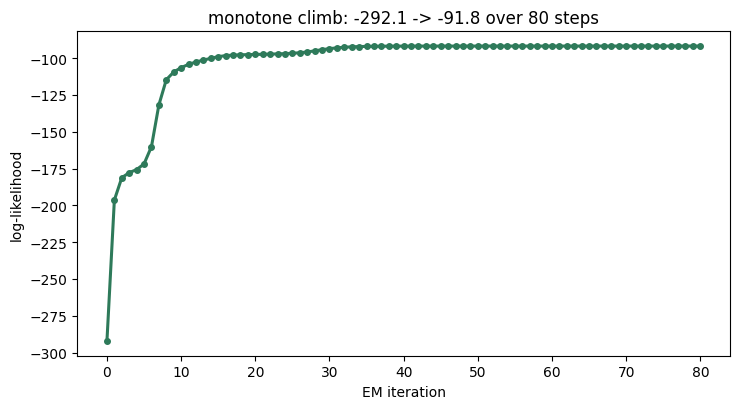

converged in 81 iterations; log-likelihood rose every step (asserted).


In [7]:
history = em_history(petal.x, IRIS_K)
lls = [s.log_likelihood for s in history]
assert all(lls[i + 1] >= lls[i] - 1e-6 for i in range(len(lls) - 1)), 'log-likelihood must never fall'
plt.figure(figsize=(7.5, 4.2))
plt.plot(range(len(lls)), lls, 'o-', color='#2E7A5A', ms=4, lw=2.2)
plt.xlabel('EM iteration')
plt.ylabel('log-likelihood')
plt.title(f'monotone climb: {lls[0]:.1f} -> {lls[-1]:.1f} over {len(lls)-1} steps')
plt.tight_layout()
plt.show()
print(f'converged in {len(lls)} iterations; log-likelihood rose every step (asserted).')

## Step 7 — See it converge: the covariance ellipses migrating

The same run, drawn. Each component's **2σ covariance ellipse** starts poorly placed and migrates to hug a species, learning its location, shape, *and* tilt. Point colours blend the three components by responsibility and sharpen as the fit improves — the soft assignment made visible.

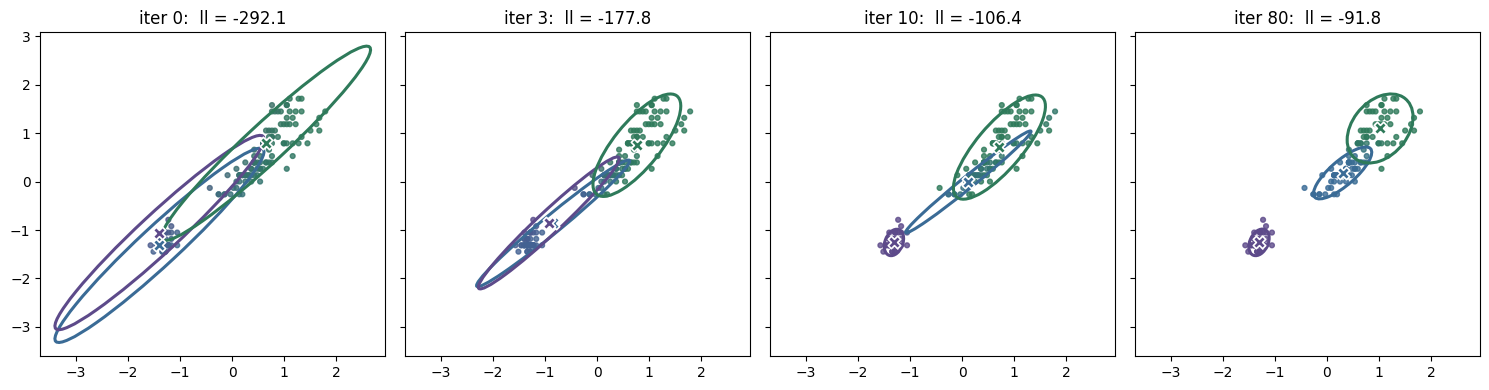

In [8]:
from matplotlib.patches import Ellipse
def draw_ellipse(ax, mean, cov, colour, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse(mean, w, h, angle=ang, fill=False, edgecolor=colour, lw=2.2))
    ax.scatter(*mean, marker='X', s=80, color=colour, edgecolor='white', lw=1.2, zorder=5)
cols = np.array([[0.227, 0.420, 0.588], [0.365, 0.290, 0.541], [0.180, 0.478, 0.353]])
panels = [0, 3, 10, len(history) - 1]
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=True)
for ax, it in zip(axes, panels):
    snap = history[it]
    ax.scatter(petal.x[:, 0], petal.x[:, 1], s=12, c=np.clip(snap.resp @ cols, 0, 1), alpha=0.8)
    for c in range(IRIS_K):
        draw_ellipse(ax, snap.means[c], snap.covs[c], ['#3A6B96', '#5D4A8A', '#2E7A5A'][c])
    ax.set_title(f'iter {it}:  ll = {snap.log_likelihood:.1f}')
plt.tight_layout()
plt.show()

## Step 8 — Is it the real thing? Verify against scikit-learn on real Iris

Cluster standardized **Iris** with our `GMMScratch` and scikit-learn's `GaussianMixture` (same k, full covariance, k-means init, seed). Because **component labels are arbitrary**, we compare the **log-likelihood** (the objective) and the **adjusted Rand index** (agreement up to a permutation), never raw labels. A match on both is the honest proof our EM is genuine.

In [9]:
match = verify_against_sklearn(iris, k=IRIS_K)
print(f'from-scratch log-likelihood : {match.scratch_ll:.4f}')
print(f'scikit-learn log-likelihood : {match.sklearn_ll:.4f}')
print(f'ARI (from-scratch vs sklearn): {match.ari_scratch_vs_sklearn:.4f}   (1.0 = same partition)')
assert abs(match.scratch_ll - match.sklearn_ll) < 0.5
assert match.ari_scratch_vs_sklearn > 0.95
print('\n=> same log-likelihood, same partition: the from-scratch EM is the real thing.')

from-scratch log-likelihood : -290.5311
scikit-learn log-likelihood : -290.5390
ARI (from-scratch vs sklearn): 1.0000   (1.0 = same partition)

=> same log-likelihood, same partition: the from-scratch EM is the real thing.


## Step 9 — Soft beats hard on overlapping data

Two of Iris's species (*versicolor*, *virginica*) overlap heavily. Because the GMM fits each species its own elliptical covariance and keeps the fence points soft, it recovers the three species **better** than k-means' hard, round cells. We know the true species here, so we can score both with the adjusted Rand index.

In [10]:
print('full 4-D Iris:')
print(f'  GMM     ARI vs true species : {match.scratch_ari_truth:.4f}')
print(f'  k-means ARI vs true species : {match.kmeans_ari_truth:.4f}')
petal_gmm, petal_km = soft_vs_hard_ari(petal, k=IRIS_K)
print('real 2-D petal plane (the soft-vs-hard figure):')
print(f'  GMM     ARI vs true species : {petal_gmm:.4f}')
print(f'  k-means ARI vs true species : {petal_km:.4f}')
print('\n=> in both views the GMM is closer to the truth — soft, elliptical fitting on overlapping, '
      'non-spherical data.')

full 4-D Iris:
  GMM     ARI vs true species : 0.9039
  k-means ARI vs true species : 0.6201
real 2-D petal plane (the soft-vs-hard figure):
  GMM     ARI vs true species : 0.9410
  k-means ARI vs true species : 0.8857

=> in both views the GMM is closer to the truth — soft, elliptical fitting on overlapping, non-spherical data.


## Step 10 — GMM succeeds where k-means fails: the anisotropic clusters

These are the **exact** sheared blobs [k-means fails on in chapter 01](../../01-K-Means-Clustering/01-K-Means-Clustering.md) (same shear, same seed). k-means draws round Voronoi cells that cut across the diagonal stripes; a full-covariance GMM fits a tilted ellipse to each stripe and recovers them. The covariance matrix is the whole difference.

In [11]:
shape = compare_shape(load_anisotropic(), k=3)
print(f'full-covariance GMM : ARI = {shape.gmm_ari:.4f}')
print(f'k-means             : ARI = {shape.kmeans_ari:.4f}')
assert shape.gmm_ari > 0.9 and shape.kmeans_ari < 0.8
print('\n=> the GMM recovers the stripes perfectly; k-means cannot represent their shape.')

full-covariance GMM : ARI = 1.0000
k-means             : ARI = 0.6585

=> the GMM recovers the stripes perfectly; k-means cannot represent their shape.


## Step 11 — Covariance types: full / tied / diag / spherical

The covariance parameterization trades flexibility against parameter count: **full** (any tilted ellipse), **tied** (one shared full covariance), **diag** (axis-aligned), **spherical** (a circle, ≈ k-means). On these blobs all three clusters share the *same* shear, so **tied** captures the tilt with the fewest parameters — the BIC winner. `diag`/`spherical` cannot tilt, so they misfit.

In [12]:
cov = compare_covariance_types(load_anisotropic(), k=3)
print(f"{'type':<11}{'n_params':>9}{'BIC':>11}{'ARI':>8}")
for name, n_params, bic, ari in cov.rows:
    print(f'{name:<11}{n_params:>9}{bic:>11.1f}{ari:>8.3f}')
print('\n=> tied wins BIC here (shared shear); diag/spherical misfit the tilt (low ARI).')

type        n_params        BIC     ARI
full              17     2896.2   1.000
tied              11     2867.3   1.000
diag              14     3890.5   0.548
spherical         11     3942.4   0.653

=> tied wins BIC here (shared shear); diag/spherical misfit the tilt (low ARI).


## Step 12 — Choosing k with BIC / AIC

The raw likelihood **always** rises with more components, so it cannot pick $k$. **BIC** $=-2\ell+p\log N$ and **AIC** $=-2\ell+2p$ tax the parameter count $p$, giving a genuine minimum. On controlled data with three true clusters, both bottom out at the true $k=3$; BIC's heavier $\log N$ penalty makes it the more conservative pick.

In [13]:
sel = select_k(load_blobs_3())
print(f"{'k':>3}{'BIC':>11}{'AIC':>11}")
for k, b, a in zip(sel.ks, sel.bic, sel.aic):
    mark = '  <- min' if k == sel.best_k_bic else ''
    print(f'{k:>3}{b:>11.1f}{a:>11.1f}{mark}')
print(f'\nBIC picks k={sel.best_k_bic}, AIC picks k={sel.best_k_aic} — both the true count.')
assert sel.best_k_bic == 3

  k        BIC        AIC
  1     6224.8     6203.8
  2     4590.9     4544.5
  3     3988.2     3916.6  <- min
  4     4018.5     3921.5
  5     4048.5     3926.3
  6     4079.8     3932.3
  7     4114.1     3941.3
  8     4146.8     3948.7

BIC picks k=3, AIC picks k=3 — both the true count.


## Step 13 — The k-means limit: k-means is a GMM at zero temperature

k-means is the GMM with equal **spherical** covariances $\Sigma_k=\sigma^2 I$ in the limit $\sigma^2\to 0$. The spherical responsibility is a **softmax over negative squared distances** with temperature $\sigma^2$; shrinking $\sigma^2$ sharpens it toward a hard argmax. Measured: a spherical-covariance GMM's hard predictions agree almost perfectly with k-means, and the responsibility hardens as the temperature drops.

In [14]:
gmm_vs_km, km_truth, sph_truth = kmeans_limit_ari(load_blobs_3(), k=3)
print(f'spherical-GMM predictions vs k-means labels : ARI = {gmm_vs_km:.4f}  (they coincide)')
for sigma2 in (2.0, 0.2, 0.02):
    g = temperature_responsibility((1.0, 4.0), sigma2)
    print(f'  responsibility (sq-dists 1 & 4) at sigma^2={sigma2:<4} : {g:.4f}')
print('\n=> as sigma^2 -> 0 the soft assignment becomes hard: k-means is GMM-EM at zero temperature.')

spherical-GMM predictions vs k-means labels : ARI = 1.0000  (they coincide)
  responsibility (sq-dists 1 & 4) at sigma^2=2.0  : 0.6792
  responsibility (sq-dists 1 & 4) at sigma^2=0.2  : 0.9994
  responsibility (sq-dists 1 & 4) at sigma^2=0.02 : 1.0000

=> as sigma^2 -> 0 the soft assignment becomes hard: k-means is GMM-EM at zero temperature.


## Recap

On real scikit-learn data (plus a clearly-labelled controlled illustration), one runnable notebook built the whole of GMM + EM:

| Step | What we measured | The takeaway |
|---|---|---|
| 1–3 | mixture density; responsibility; one E/M step by hand | soft, Bayes-rule assignments; the M-step is weighted MLE |
| 4–5 | E-step (log-sum-exp); M-step closed forms | responsibilities sum to 1; soft counts drive the updates |
| 6–7 | the EM loop; ellipses migrating | log-likelihood **rises monotonically** to convergence |
| 8 | verify vs scikit-learn (Iris) | **same log-likelihood, ARI = 1.0** — the from-scratch EM is genuine |
| 9 | soft vs hard (Iris) | GMM recovers overlapping species better (ARI 0.90 vs 0.62) |
| 10 | anisotropic blobs | GMM **ARI 1.00** vs k-means 0.66 — covariance is the difference |
| 11–12 | covariance types; BIC/AIC | tied wins on shared-shear data; both criteria pick true k=3 |
| 13 | the k-means limit | spherical GMM ≈ k-means; hard is the zero-temperature limit |

**A GMM models data as $p(x)=\sum_k\pi_k\mathcal{N}(x;\mu_k,\Sigma_k)$ and is fit by EM — an E-step that computes soft responsibilities (tightening a lower bound on the likelihood) and a closed-form M-step (raising it), so the log-likelihood never decreases and converges to a local optimum.** It gives you soft assignments, elliptical clusters, a density to sample and score, and BIC for model selection — everything k-means throws away. And EM generalizes far beyond GMMs: HMMs, missing data, and the variational objective behind modern generative models.